 # Question 1: Wage discrimination in starting salaries
 Does wage discrimination exist in the starting salaries of faculty members (i.e., salaries in the year hired)?

## 1. Data loading

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import scipy.stats as stats
salaries = pd.read_csv("salary.txt", sep=r"\s+")

In [3]:
#Filtering out starting salaries 
starting_salaries = salaries[salaries["year"] == salaries["startyr"]].copy()

## 1. Data Exploration

[]

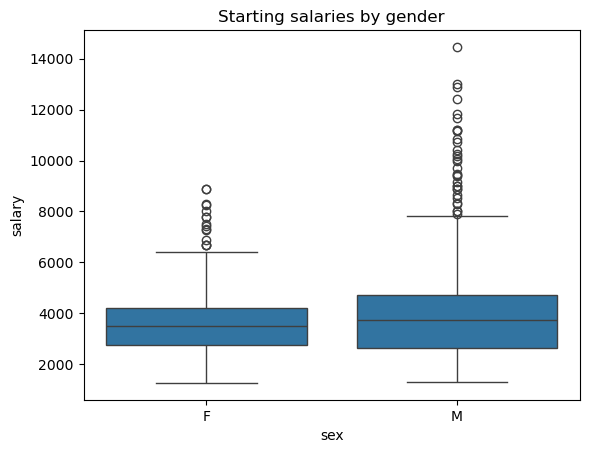

In [16]:
# Generally plotting salaries for each sex to see if there is an observable difference.
sns.boxplot(data = starting_salaries, x = "sex", y ="salary")
plt.title ("Starting salaries by gender")
plt.plot()


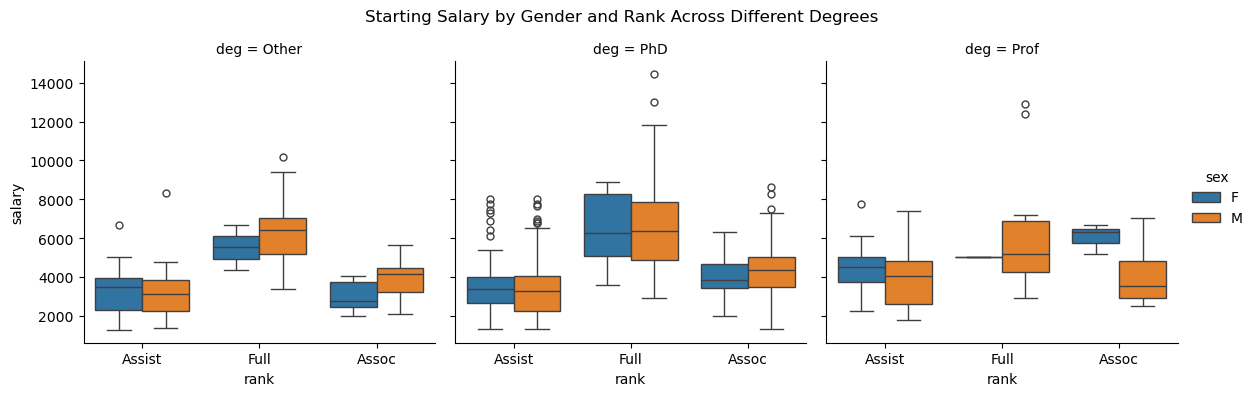

In [17]:
#Now doing some data exploration to observe for any patterns in the data before we start using numerical methos.
g = sns.catplot(
    data=starting_salaries,
    x="rank",
    y="salary",
    col="deg",
    hue="sex",
    kind="box",
    height=4,
    aspect=1
)

g.fig.suptitle("Starting Salary by Gender and Rank Across Different Degrees")

g.fig.subplots_adjust(top=0.85)  # pushes plots down

plt.show()

Now since generally one's years since their highest degree which can also be years they might have been in the industry might affect their starting salary, we can create a new field called "years_since_degree" to see if there is any observable pattern between experience and starting salary
This field is to help observe any patterns between time spent before being hired, starting salary, and sex.

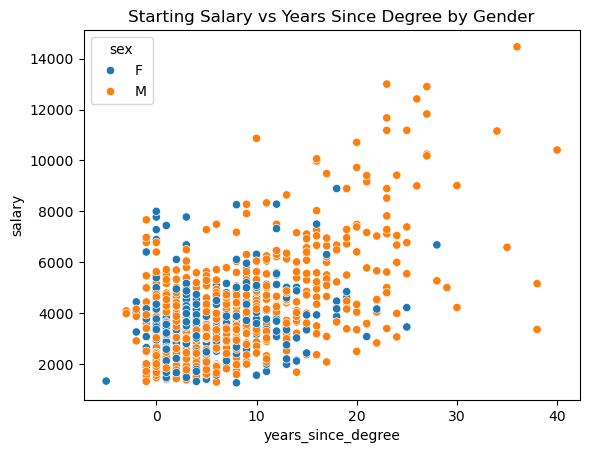

In [21]:

starting_salaries["years_since_degree"] = starting_salaries["startyr"] - starting_salaries["yrdeg"]
sns.scatterplot(data = starting_salaries, x = "years_since_degree", y = "salary", hue = "sex")
plt.title("Starting Salary vs Years Since Degree by Gender")  # <-- set title here
plt.show()

## 2. Numerical summaries

  sex  median_salary  mean_salary  count
0   F         3502.5  3600.322901    354
1   M         3719.0  4015.545388    753


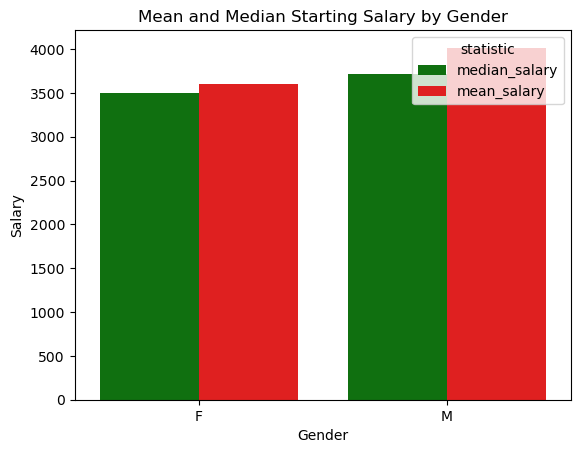

In [28]:
# Getting numeric summary statistics for salaries by sex
starting_salary_summary = starting_salaries.groupby("sex").agg(
    median_salary=("salary", "median"),
    mean_salary=("salary", "mean"),
    count=("salary", "count")
).reset_index() 
print (starting_salary_summary)

starting_salary_melted = starting_salary_summary.melt(
    id_vars='sex', 
    value_vars=['median_salary', 'mean_salary'], 
    var_name='statistic', 
    value_name='salary'
)

sns.barplot(data=starting_salary_melted, x='sex', y='salary', hue='statistic', palette=['green','red'])
plt.title("Mean and Median Starting Salary by Gender")
plt.ylabel("Salary")
plt.xlabel("Gender")
plt.show()

Checking for correlation between gender and starting salary

In [23]:

starting_salaries['sex_numeric'] = starting_salaries['sex'].map({'F': 0, 'M': 1}) 
correlation = starting_salaries['salary'].corr(starting_salaries['sex_numeric']) 
print("Correlation between starting salary and gender:", correlation)


Correlation between starting salary and gender: 0.10901192566702936


After checking for correlation between gender and starting salary, we observe that there is a very weak positive of 0.1 association between gender and starting salary, with males earning more on average.



## 3. Statistical Methods
Now that we have an idea of the data, we can start statistically assessing the data
First we will use a multiple linear regression model predicting salary from sex, field, degree, experience, rank, and admin.

In [7]:

model = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.387
Model:                            OLS   Adj. R-squared:                  0.382
Method:                 Least Squares   F-statistic:                     77.10
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          2.14e-110
Time:                        19:13:04   Log-Likelihood:                -9582.5
No. Observations:                1107   AIC:                         1.918e+04
Df Residuals:                    1097   BIC:                         1.924e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           2378.9852    175

From the above we observe that statistically significant predictors are Statistically significant predictors are rank, experience, and field.

Next we use ANOVA to also test whether removing sex would affect the model.

In [8]:
# Test removing gender
model_full = smf.ols(
    "salary ~ sex + field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

model_reduced_gender = smf.ols(
    "salary ~ field + deg + years_since_degree + rank + admin",
    data=starting_salaries
).fit()

anova_lm(model_reduced_gender, model_full)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,1098.0,2.144679e+09,0.0,NaN,NaN,NaN
1,1097.0,2.139902e+09,1.0,4.777297e+06,2.449035,0.117886


From the above we observe a p value of 0.118 which means that removing gender would not significantly affect starting salaries, if we assume an non interactive model.

Next we will create an interactive model to see if there are any interactions between the predictors and gender.

This can help us observe if their are any interaction with gender that might point to starting salary discrimation by gender.

In [9]:
#Interactive model

model2 = smf.ols(
    "salary ~ sex * (field + deg + years_since_degree + rank)",
    data=starting_salaries
).fit()

# Extracting coefficients table
results_df = pd.DataFrame({
    "coef": model2.params,
    "p_value": model2.pvalues,
    "t_value": model2.tvalues
})

# Sorting by p-value ascending to see if there is any sex interaction that is significant
results_df_sorted = results_df.sort_values(by="p_value", ascending=True)
print (results_df_sorted)


                                    coef       p_value    t_value
Intercept                    2767.757714  8.160398e-25  10.542860
rank[T.Full]                 2514.079953  2.790647e-09   5.993290
field[T.Prof]                1059.483221  4.107787e-04   3.544006
sex[T.M]:years_since_degree    73.554162  5.070323e-04   3.487471
deg[T.Prof]                  1060.855181  9.462377e-03   2.599487
field[T.Other]                403.518456  3.585912e-02   2.101123
sex[T.M]                     -679.991304  5.171760e-02  -1.947612
rank[T.Assoc]                 449.409384  9.105402e-02   1.691358
sex[T.M]:deg[T.Prof]         -748.244009  1.276328e-01  -1.524664
sex[T.M]:rank[T.Full]        -623.107049  1.879918e-01  -1.317368
years_since_degree             16.658941  3.526790e-01   0.929803
deg[T.PhD]                    194.027645  4.066367e-01   0.830148
sex[T.M]:deg[T.PhD]           256.285761  4.106702e-01   0.823031
sex[T.M]:field[T.Prof]       -243.854643  4.953294e-01  -0.682086
sex[T.M]:f

We then observe that is only significant when there is experience (5.070323e-04) 

We then observe that there is relevance gender almost insignificant with p value of 0.0517 but close eniugh to be considerable.

Therefore we will analyse using permutations to see if we randomly assign gender, whether we observe that it is by chance that the observed differences in starting salary are by chance. 

The null hypothesis we will be testing for, is that there is no difference between males and females starting salaries

In [10]:
#Observed difference in means (M - F)
obs_diff = (
    starting_salaries[starting_salaries["sex"] == "M"]["salary"].mean()
    - starting_salaries[starting_salaries["sex"] == "F"]["salary"].mean()
)

print(obs_diff)

415.22248665226107


In [11]:

# Permutation test
np.random.seed(123)

perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(starting_salaries["sex"])
    
    diff = (
        starting_salaries["salary"][shuffled_sex == "M"].mean()
        - starting_salaries["salary"][shuffled_sex == "F"].mean()
    )
    
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
p_value

np.float64(0.0004)

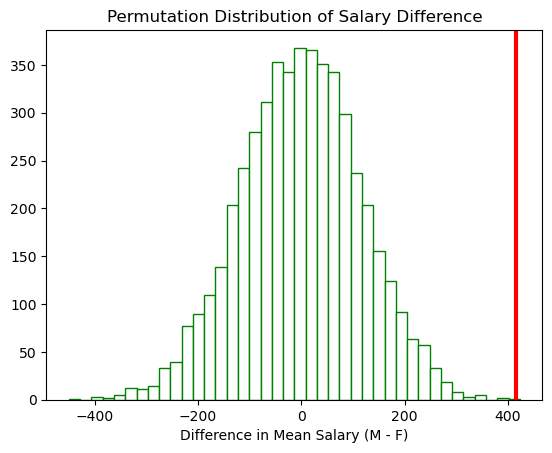

In [145]:
# Histogram of permutation distribution
plt.hist(perm_diffs, bins=40, color='white', edgecolor='green')
plt.axvline(obs_diff, linewidth=3, color='red')
plt.title("Permutation Distribution of Salary Difference")
plt.xlabel("Difference in Mean Salary (M - F)")
plt.show()

From this we can conclude that the average salary difference of $415 between males and females is extremely unlikely

Given that our null hypothesis in the permutation test is that there is no difference between males and females starting salaries, but our p value < 0.05 we reject the null hypothesis

Therefore, the observed difference is extremely unlikely to happen by chance if gender had no effect.

### Gender by Rank

In [132]:
#Select assistant professors in their first year
assist_prof_subset = starting_salaries[
    (starting_salaries["rank"] == "Assist") &
    (starting_salaries["startyr"] == starting_salaries["year"])
].copy()

In [133]:
#convert columns so they can go into the regression model
categorical_cols = ["admin", "sex", "field", "deg"]
for col in categorical_cols:
    assist_prof_subset[col] = assist_prof_subset[col].astype("category")

In [134]:
#Assist prof model (dropped admin bc only 1 point was admin == 1)
assist_lm = smf.ols(
    "salary ~ sex + field + deg + yrdeg + year",
    data=assist_prof_subset
).fit()

print("Assistant Professor Only Model")
print(assist_lm.summary())

Assistant Professor Only Model
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     245.9
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          5.96e-194
Time:                        18:14:17   Log-Likelihood:                -6382.3
No. Observations:                 802   AIC:                         1.278e+04
Df Residuals:                     794   BIC:                         1.282e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept    

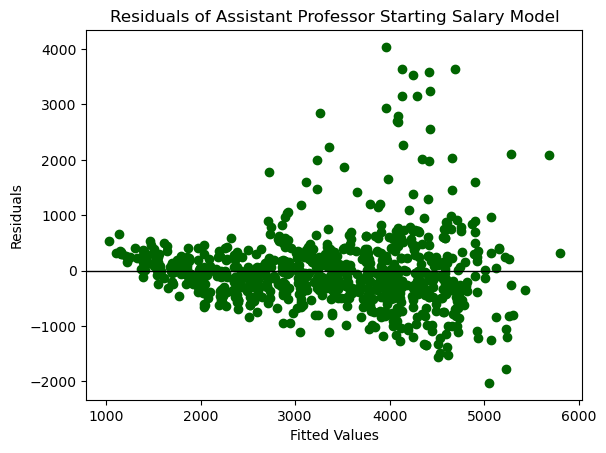

In [135]:
#Check residuals + plot
Q1_assist_residuals = assist_lm.resid
fitted_values = assist_lm.fittedvalues

plt.scatter(fitted_values, Q1_assist_residuals, color='darkgreen')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals of Assistant Professor Starting Salary Model")
plt.show()

In [136]:
#Apply robust standard errors
robust_se = assist_lm.get_robustcov_results(cov_type='HC3')
print("Final Model with Robust Standard Errors:")
print(robust_se.summary())

Final Model with Robust Standard Errors:
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     279.1
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          3.77e-209
Time:                        18:14:17   Log-Likelihood:                -6382.3
No. Observations:                 802   AIC:                         1.278e+04
Df Residuals:                     794   BIC:                         1.282e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Int

In [137]:
#Subset into female vs male
women_data = assist_prof_subset[assist_prof_subset["sex"] == "F"]
men_data = assist_prof_subset[assist_prof_subset["sex"] == "M"]

# Get the size of each just for reference
print(f"Women data points: {len(women_data)}")
print(f"Men data points: {len(men_data)}")

# Look at variance of men vs women salary for startyr
print(f"Women variance: {women_data['salary'].var()}")
print(f"Men variance: {men_data['salary'].var()}")

Women data points: 301
Men data points: 501
Women variance: 1376779.2061921288
Men variance: 1602759.3115676732


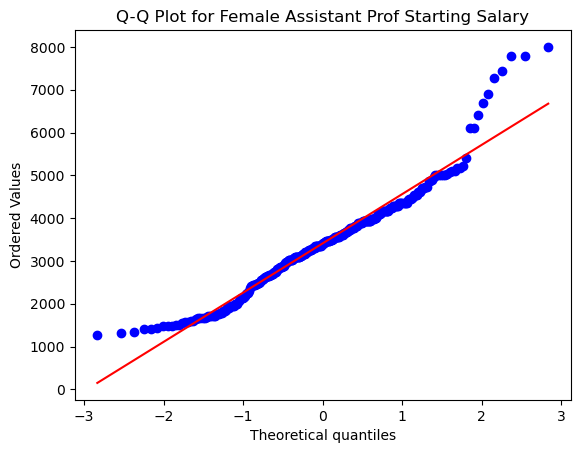

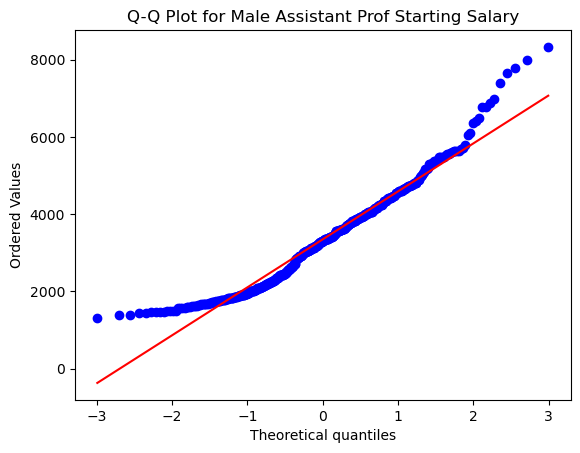

In [138]:
#Q-Q plots for starting salary
plt.figure()
stats.probplot(women_data["salary"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Female Assistant Prof Starting Salary")
plt.show()

plt.figure()
stats.probplot(men_data["salary"], dist="norm", plot=plt)
plt.title("Q-Q Plot for Male Assistant Prof Starting Salary")
plt.show()

In [139]:
#Permutation test for Assistant Profs
obs_diff = men_data["salary"].mean() - women_data["salary"].mean()

np.random.seed(123)
perm_diffs = []

for _ in range(5000):
    shuffled_sex = np.random.permutation(assist_prof_subset["sex"])
    diff = (
        assist_prof_subset["salary"][shuffled_sex == "M"].mean()
        - assist_prof_subset["salary"][shuffled_sex == "F"].mean()
    )
    perm_diffs.append(diff)

perm_diffs = np.array(perm_diffs)
assist_p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print(f"Permutation Test For Assistant Professors p-value: {assist_p_value}")

Permutation Test For Assistant Professors p-value: 0.4598
